Simulation Complete. Success:


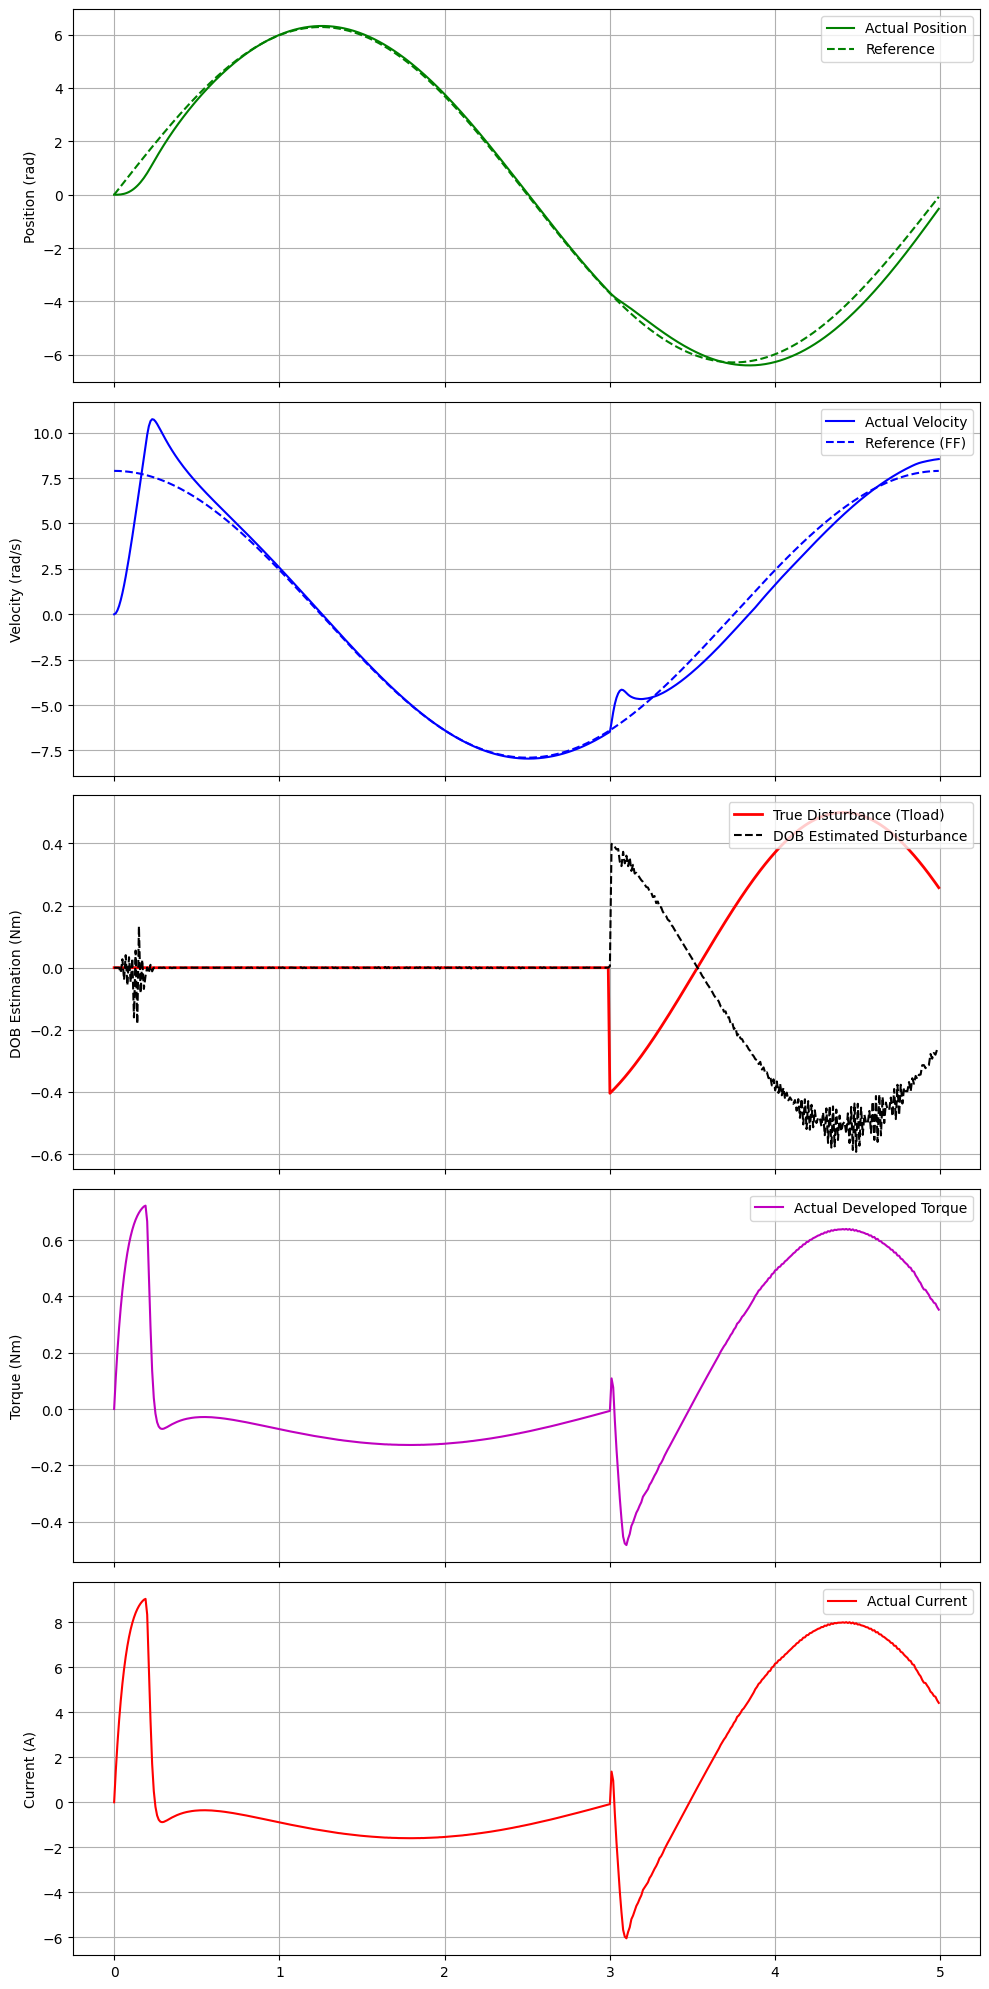

In [4]:
#Tasks to be implemented  - Apply a load profile - done and apply a disturbance observer at the node where load is being applied

import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as sci_int

Ra = 1.2
La = 0.08
Kt = 0.08
Kb = 0.08
Jm = 0.01
Bf = 0.01

V_max = 12 
T_max = 1.5
Omega_max = 4.71

Theta_amp = 360 * (np.pi / 180) #rad
Theta_freq = 0.2

Tload = 0

Omega_amp = Theta_amp * (2 * np.pi * Theta_freq)



x0 = [0, 0, 0,0]

startTime = 0
endTime = 5
dt = 0.01
t_eval = np.arange(startTime, endTime, dt)

LoadStart = 3
LoadEnd = 7

Kp_position = 2

Kd_velocity = 0.4

Kp_current = 11
Kd_current = 0.01

def motor_plant(t, x):
    I = x[0]
    Theta = x[1]
    Omega = x[2]
    z = x[3] #internal state variable

    g = 15
    

    if t >= LoadStart and t <= LoadEnd:
        Tload = 0.5 * np.sin((2*np.pi*0.2 + (30* np.pi / 180))*t)
    else :
        Tload = 0

    Theta_ref = Theta_amp * np.sin(2 * np.pi * Theta_freq * t)
    Omega_ref_ff = Theta_amp * 2 * np.pi * Theta_freq * np.cos(2 * np.pi * Theta_freq * t)
    
    error_theta = Theta_ref - Theta
    #derror_theta = Omega_ref_ff - Omega
    
    # Omega_cmd = (Kp_position * error_theta) + (Kd_position * derror_theta)

    error_Omega = Omega_ref_ff - Omega
    
    #domega_actual = (Kt * I - Bf * Omega - Tload) / Jm
    #derror_Omega = -domega_actual
    
    Tload_est = z + g * Omega
    dz = (-g / Jm) * z - (g / Jm) * (Kt * I - Bf * Omega) - ((g**2) / Jm) * Omega

    T_cmd = (Kp_position * error_theta) + (Kd_velocity * error_Omega) + Tload_est
    
    T_cmd = np.clip(T_cmd, -T_max, T_max)
    I_cmd = T_cmd / Kt

    error_current = I_cmd - I
    
    numerator = (Kp_current * error_current) + (Kd_current / La) * (Ra * I + Kb * Omega)
    denominator = 1 + (Kd_current / La)
    V_cmd = numerator / denominator

    V_app = np.clip(V_cmd, -V_max, V_max)
    
    dtheta = Omega 
    domega = (Kt * I - Bf * Omega - Tload) / Jm  
    dcurrent = (V_app - Ra * I - Kb * Omega) / La
    
    return [dcurrent, dtheta, domega,dz]
    
solution = sci_int.solve_ivp(
    motor_plant,
    t_eval=t_eval,
    t_span=(startTime, endTime),
    y0=x0,
    method='RK45',
    max_step =0.01,
    first_step = 0.01
)

def plot_dob_motor_results(solution,g):
    t = solution.t
    I = solution.y[0]
    Theta = solution.y[1]
    Omega = solution.y[2]
    z = solution.y[3]

    # Reconstruct variables for tracking visualizer
    Tload = np.where(
        (t >= LoadStart) & (t <= LoadEnd), 
        0.5 * np.sin((2*np.pi*0.2 + (30* np.pi / 180))*t), 
        0
    )
    
    Tload_est = z + g * Omega
    Theta_ref = Theta_amp * np.sin(2 * np.pi * Theta_freq * t)
    Omega_ref_ff = Theta_amp * 2 * np.pi * Theta_freq * np.cos(2 * np.pi * Theta_freq * t)
    
    T_actual = Kt * I

    
    fig, axs = plt.subplots(5, 1, figsize=(10, 20), sharex=True)
    
    # Position Plot
    axs[0].plot(t, Theta, color='g', label='Actual Position')
    axs[0].plot(t, Theta_ref, color='g', linestyle='--', label='Reference')
    axs[0].set_ylabel('Position (rad)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)
    
    # Velocity Plot
    axs[1].plot(t, Omega, color='b', label='Actual Velocity')
    axs[1].plot(t, Omega_ref_ff, color='b', linestyle='--', label='Reference (FF)')
    axs[1].set_ylabel('Velocity (rad/s)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)
    
    # Disturbance Observer Tracking Plot
    axs[2].plot(t, Tload, color='r', linewidth=2, label='True Disturbance (Tload)')
    axs[2].plot(t, Tload_est, color='k', linestyle='--', linewidth=1.5, label='DOB Estimated Disturbance')
    axs[2].set_ylabel('DOB Estimation (Nm)')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)
    
    # Torques Plot
    axs[3].plot(t, T_actual, color='m', label='Actual Developed Torque')
    axs[3].set_ylabel('Torque (Nm)')
    axs[3].legend(loc='upper right')
    axs[3].grid(True)
    
    # Current Plot
    axs[4].plot(t, I, color='r', label='Actual Current')
    axs[4].set_ylabel('Current (A)')
    axs[4].legend(loc='upper right')
    axs[4].grid(True)
    
    plt.tight_layout()
    plt.show()

print("Simulation Complete. Success:")
plot_dob_motor_results(solution,g = 15)